In [90]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df = pd.read_csv(r"C:\Users\vedan\PycharmProjects\AI-ML\Day 2 - Assesment difficulty prediction\data\cleaned_student_assessment_data.csv")
df.drop("student_id", axis=1, inplace=True)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 28)


,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,difficulty_score,learning_velocity,passed,question_difficulty_easy,question_difficulty_hard,question_difficulty_medium,question_difficulty_very_hard,total_study_effort,avg_study_effort,study_consistency,max_study_effort,min_study_effort,ability_score,total_score,score_consistency,max_score,min_score,preparedness_score,study_efficiency,performance_stability
0,12.881202,7.964516,11.426307,78.482862,76.814937,68.038282,1,3,2,-8.229587,1,0.0,0.0,1.0,0.0,33.272025,8.318006,5.296617,12.881202,1.000000,56.334020,225.336082,36.511253,78.482862,2.0,41.929216,6.045716,0.026659
1,12.732929,9.083502,11.869376,77.833236,68.402106,64.120886,3,2,2,-0.946706,1,0.0,0.0,1.0,0.0,36.685807,9.171452,4.399147,12.732929,3.000000,53.089057,212.356227,34.537694,77.833236,2.0,39.913775,5.219418,0.028139
2,6.021784,8.207857,12.257180,65.634802,75.616487,75.424149,14,3,2,-0.459076,0,0.0,0.0,1.0,0.0,40.486820,10.121705,3.654841,14.000000,6.021784,54.668859,218.675437,35.420549,75.616487,2.0,41.304713,4.915511,0.027457
3,13.349549,10.331254,15.787446,80.795842,88.263725,88.875034,12,2,1,1.692599,1,1.0,0.0,0.0,0.0,51.468249,12.867062,2.305324,15.787446,10.331254,64.733650,258.934601,42.647560,88.875034,1.0,49.173674,4.668159,0.022911
4,18.664145,13.591536,9.011131,60.099173,69.644368,71.286809,5,4,2,4.772185,1,0.0,0.0,1.0,0.0,46.266812,11.566703,5.891411,18.664145,5.000000,50.757587,203.030350,32.877180,71.286809,2.0,39.000322,4.039054,0.029518


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   study_hours_per_week           5000 non-null   float64
 1   hours_studied_for_assessment   5000 non-null   float64
 2   study_sessions_last_30_days    5000 non-null   float64
 3   engagement_score               5000 non-null   float64
 4   previous_scores                5000 non-null   float64
 5   avg_previous_score             5000 non-null   float64
 6   days_since_last_study          5000 non-null   int64  
 7   avg_attempts_per_assessment    5000 non-null   int64  
 8   difficulty_score               5000 non-null   int64  
 9   learning_velocity              5000 non-null   float64
 10  passed                         5000 non-null   int64  
 11  question_difficulty_easy       5000 non-null   float64
 12  question_difficulty_hard       5000 non-null   f

## Prepare Features and Target

In [93]:
x = df.drop('passed', axis=1)
y = df['passed']
print("Feature Shape:", x.shape)
print("Target Shape:", y.shape)

Feature Shape: (5000, 27)
Target Shape: (5000,)


## Train-Test Split

In [94]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

x_train: (4000, 27)
x_test: (1000, 27)


## Standard Scaling

In [95]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Cross Validation Setup

In [96]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression

In [97]:
model = LogisticRegression(max_iter=1000, random_state=42)

scores = cross_validate(
    model,
    x_train_scaled,
    y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

print("Logistic Regression CV Accuracy:",
      scores['test_accuracy'].mean())

print("Logistic Regression CV Precision:",
      scores['test_precision'].mean())

print("Logistic Regression CV Recall:",
      scores['test_recall'].mean())

print("Logistic Regression CV F1 Score:",
      scores['test_f1'].mean())

Logistic Regression CV Accuracy: 0.8905000000000001
Logistic Regression CV Precision: 0.9071667761813546
Logistic Regression CV Recall: 0.9198519296069214
Logistic Regression CV F1 Score: 0.9133565426938871


In [98]:
model.fit(x_train_scaled, y_train)

preds = model.predict(x_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Test Accuracy: 0.923

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       373
           1       0.94      0.94      0.94       627

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



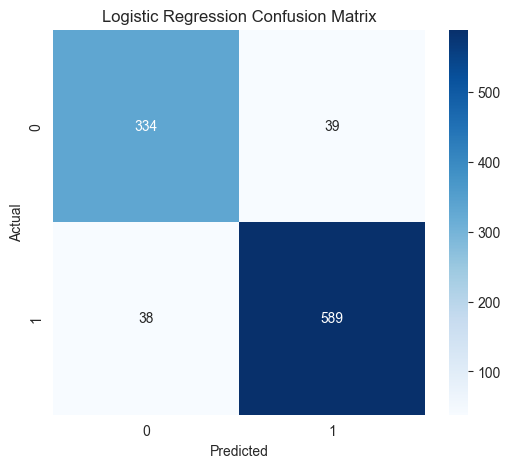

In [99]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest Classifier

In [100]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)

rf_scores = cross_validate(
    rf_model,
    x_train,
    y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

print("Random Forest CV Accuracy:", rf_scores['test_accuracy'].mean())
print("Random Forest CV Precision:", rf_scores['test_precision'].mean())
print("Random Forest CV Recall:", rf_scores['test_recall'].mean())
print("Random Forest CV F1 Score:", rf_scores['test_f1'].mean())

Random Forest CV Accuracy: 0.8664999999999999
Random Forest CV Precision: 0.8817426845864527
Random Forest CV Recall: 0.9098830227990234
Random Forest CV F1 Score: 0.8953700788508229


In [101]:
rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))

Test Accuracy: 0.883

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       373
           1       0.90      0.91      0.91       627

    accuracy                           0.88      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.88      0.88      0.88      1000



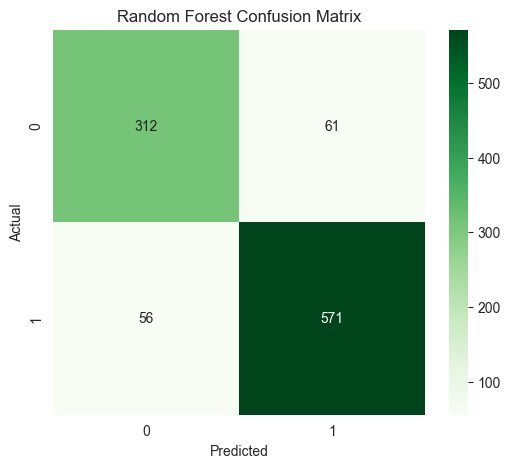

In [102]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest Feature Importance

In [103]:
importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
importance_df.head(15)

,Feature,Importance
0,study_hours_per_week,0.122060
16,study_consistency,0.080616
23,min_score,0.071418
8,difficulty_score,0.069377
21,score_consistency,0.069025
26,performance_stability,0.061197
24,preparedness_score,0.050284
20,total_score,0.047065
17,max_study_effort,0.045279
19,ability_score,0.043681


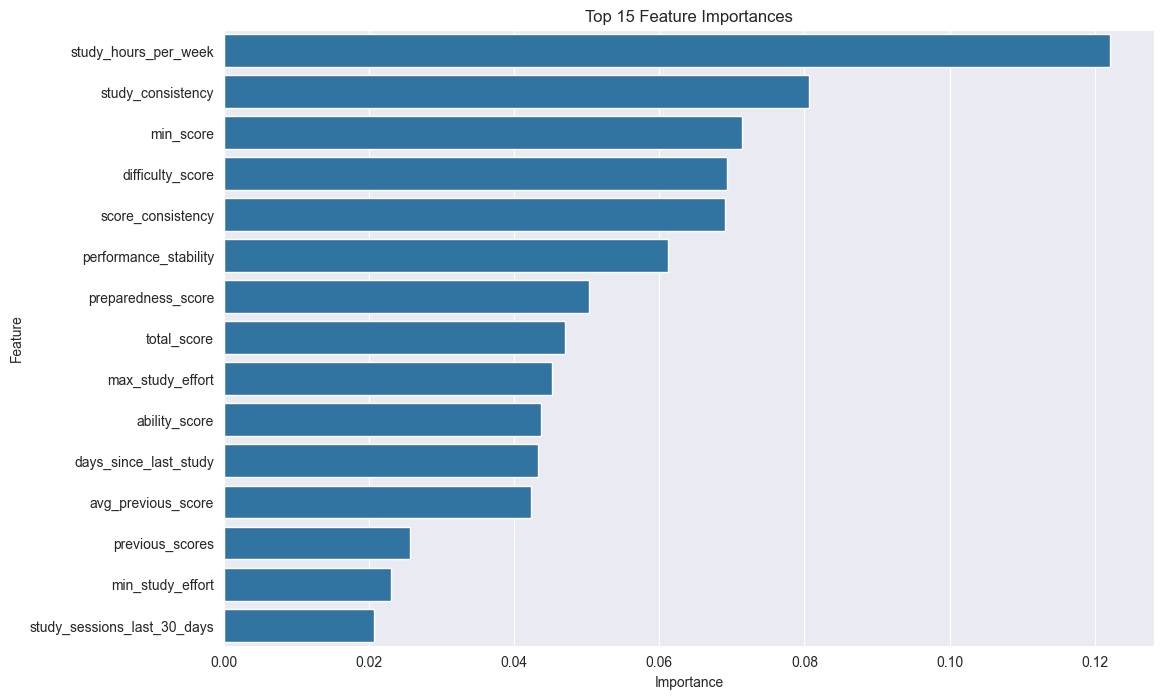

In [104]:
plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)

plt.title("Top 15 Feature Importances")
plt.show()

# XGBoost Classifier

In [105]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_scores = cross_validate(
    xgb_model,
    x_train,
    y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

print("XGBoost CV Accuracy:", xgb_scores['test_accuracy'].mean())
print("XGBoost CV Precision:", xgb_scores['test_precision'].mean())
print("XGBoost CV Recall:", xgb_scores['test_recall'].mean())
print("XGBoost CV F1 Score:", xgb_scores['test_f1'].mean())

XGBoost CV Accuracy: 0.8727499999999999
XGBoost CV Precision: 0.8922971354159192
XGBoost CV Recall: 0.907093382955205
XGBoost CV F1 Score: 0.8994585527287349


In [106]:
xgb_model.fit(x_train, y_train)

xgb_preds = xgb_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))

Test Accuracy: 0.901

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.86      0.87       373
           1       0.92      0.93      0.92       627

    accuracy                           0.90      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.90      0.90      0.90      1000



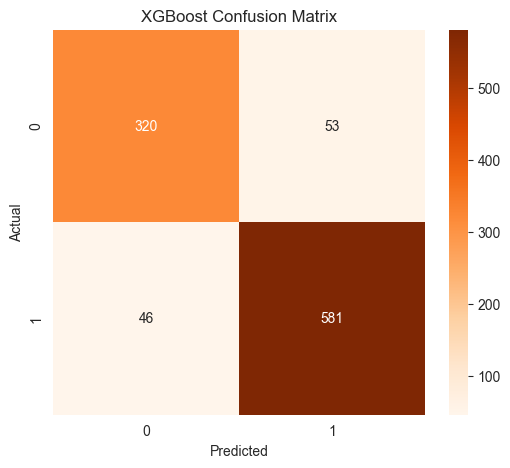

In [107]:
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Pass Probability Prediction

In [108]:
rf_probabilities = rf_model.predict_proba(x_test)
pass_probability = rf_probabilities[:, 1]

probability_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Probability': pass_probability
})
probability_df.head()

,Actual,Predicted_Probability
0,1,0.875294
1,0,0.300523
2,1,0.491062
3,0,0.478906
4,0,0.242767


# Model Comparison

In [109]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'CV Accuracy': [
        scores['test_accuracy'].mean(),
        rf_scores['test_accuracy'].mean(),
        xgb_scores['test_accuracy'].mean()
    ],

    'CV Precision': [
        scores['test_precision'].mean(),
        rf_scores['test_precision'].mean(),
        xgb_scores['test_precision'].mean()
    ],

    'CV Recall': [
        scores['test_recall'].mean(),
        rf_scores['test_recall'].mean(),
        xgb_scores['test_recall'].mean()
    ],

    'CV F1 Score': [
        scores['test_f1'].mean(),
        rf_scores['test_f1'].mean(),
        xgb_scores['test_f1'].mean()
    ]
})

comparison_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score
0,Logistic Regression,0.89050,0.907167,0.919852,0.913357
1,Random Forest,0.86650,0.881743,0.909883,0.895370
2,XGBoost,0.87275,0.892297,0.907093,0.899459
